# Resident Incident Risk Predictor
## Faro Safehouse — INTEX W26


---

### Business Question

**Which residents are at highest risk for serious behavioral incidents (runaway attempts or self-harm)?**

Faro Safehouse operates residential care facilities in Chile for survivors of trafficking and abuse. Caseworkers manage caseloads of 60+ residents, each with complex trauma histories, ongoing counseling sessions, health monitoring, and educational programming. The challenge is that caseworkers cannot give equal intensive attention to every resident simultaneously — they need to know *which* residents require the most urgent monitoring.

### Why This Matters

Two incident types carry the highest stakes:

- **Runaway attempts** endanger girls who may be re-trafficked or returned to abusive environments. A successful runaway can undo months of rehabilitation and place the survivor in immediate physical danger.
- **Self-harm** requires immediate clinical response and indicates a resident is in acute psychological distress. Early identification allows caseworkers to intervene with additional counseling, safety planning, and peer support before a crisis occurs.

A predictive model that flags high-risk residents enables proactive intervention rather than reactive crisis management.

### Predictive vs. Explanatory Framing

This pipeline is primarily **predictive** — we want accurate probability estimates for each resident to prioritize caseworker attention. The model produces a risk score (0-100%) and a risk label (Low / Moderate / High) for every resident, updated nightly.

We also build an **explanatory model** (statsmodels Logit) to understand which factors drive incident risk and inform organizational policy. For example, if low counseling engagement is strongly associated with incidents, the organization can mandate minimum session frequencies.

### Success Metrics

| Metric | Role |
|--------|------|
| **ROC-AUC** (primary) | Measures discrimination ability across all thresholds; handles class imbalance well |
| **F1 Score** | Balances precision and recall at the default 0.5 threshold |
| **Accuracy vs. Baseline** | Ensures the model outperforms naive majority-class prediction |

### Why This Target Replaced the Original

The original target variable was "reintegration readiness," defined as `is_ready = reintegration_status in ["Completed", "In Progress"]`. This was problematic because "In Progress" does not mean "ready" — it contradicted caseworkers' own `current_risk_level` assessments. A resident coded as "In Progress" reintegration but "High" current risk was simultaneously labeled as "ready" and "at risk," creating a noisy and contradictory target.

Incident risk is measurable (binary: has the resident ever had a RunawayAttempt or SelfHarm event?), actionable (caseworkers can respond to risk flags), and directly impacts resident safety.

---

## 1. Setup and Imports

In [1]:
import re
import json
import warnings
from datetime import datetime, timezone

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm

from sklearn.compose import ColumnTransformer
from sklearn.ensemble import GradientBoostingClassifier, RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix,
    f1_score, roc_auc_score,
)
from sklearn.model_selection import (
    RepeatedStratifiedKFold, GridSearchCV, cross_val_score, train_test_split,
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.tree import DecisionTreeClassifier
from sklearn.inspection import permutation_importance

warnings.filterwarnings("ignore")
%matplotlib inline

SEED = 42
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["figure.dpi"] = 100

print("Setup complete.")

from scipy import stats
from sklearn.metrics import log_loss
from sklearn.tree import plot_tree
from sklearn.ensemble import BaggingClassifier, AdaBoostClassifier


Setup complete.


---

## 2. Data Acquisition, Preparation, and Exploration

### 2.1 Data Schema

The dataset spans six relational tables from the Faro Safehouse case management system:

| Table | Description | Grain |
|-------|-------------|-------|
| `residents` | Core demographic and case information for each resident | 1 row per resident |
| `process_recordings` | Counseling session logs: duration, emotional states, progress notes | 1 row per session |
| `health_wellbeing_records` | Periodic health assessments: nutrition, sleep, energy, BMI, checkups | 1 row per assessment |
| `education_records` | Educational program tracking: attendance, progress | 1 row per term/period |
| `incident_reports` | Behavioral incident logs: type, severity, resolution | 1 row per incident |
| `intervention_plans` | Individual care plans: goals, status (Achieved/In Progress/etc.) | 1 row per plan |

These tables are joined at the resident level. Since the `residents` table is at the resident grain (one row per person), all child tables must be aggregated (mean, count, percentage) before merging. This produces a single wide DataFrame with ~48 features per resident.

### 2.2 Load Raw Data

In [2]:
# Load all six CSV tables using relative paths from notebooks/ directory
residents    = pd.read_csv("data/residents.csv")
process_recs = pd.read_csv("data/process_recordings.csv")
health       = pd.read_csv("data/health_wellbeing_records.csv")
education    = pd.read_csv("data/education_records.csv")
incidents    = pd.read_csv("data/incident_reports.csv")
plans        = pd.read_csv("data/intervention_plans.csv")

print(f"Loaded: residents={len(residents)}, process_recs={len(process_recs)}, "
      f"health={len(health)}, education={len(education)}, "
      f"incidents={len(incidents)}, plans={len(plans)}")

residents.head(3)

Loaded: residents=60, process_recs=2819, health=534, education=534, incidents=100, plans=180


,resident_id,case_control_no,internal_code,safehouse_id,case_status,sex,date_of_birth,birth_status,place_of_birth,religion,...,initial_case_assessment,date_case_study_prepared,reintegration_type,reintegration_status,initial_risk_level,current_risk_level,date_enrolled,date_closed,created_at,notes_restricted
0,1,C0043,LS-0001,4,Active,F,2008-08-31,Marital,Davao City,Unspecified,...,For Reunification,2023-12-14,Foster Care,In Progress,Critical,High,2023-10-17,NaN,2023-10-17 00:00:00,NaN
1,2,C2530,LS-0002,3,Closed,F,2008-04-23,Marital,Cebu City,Seventh-day Adventist,...,For Continued Care,2023-04-10,Family Reunification,Completed,Medium,Medium,2023-03-18,2025-01-06,2023-03-18 00:00:00,NaN
2,3,C3946,LS-0003,1,Active,F,2007-01-31,Marital,Manila,Roman Catholic,...,For Independent Living,NaN,Foster Care,Completed,Medium,Medium,2024-05-24,NaN,2024-05-24 00:00:00,NaN


### 2.3 Exploratory Data Analysis

Before engineering features, we examine the raw distributions to understand the data landscape.

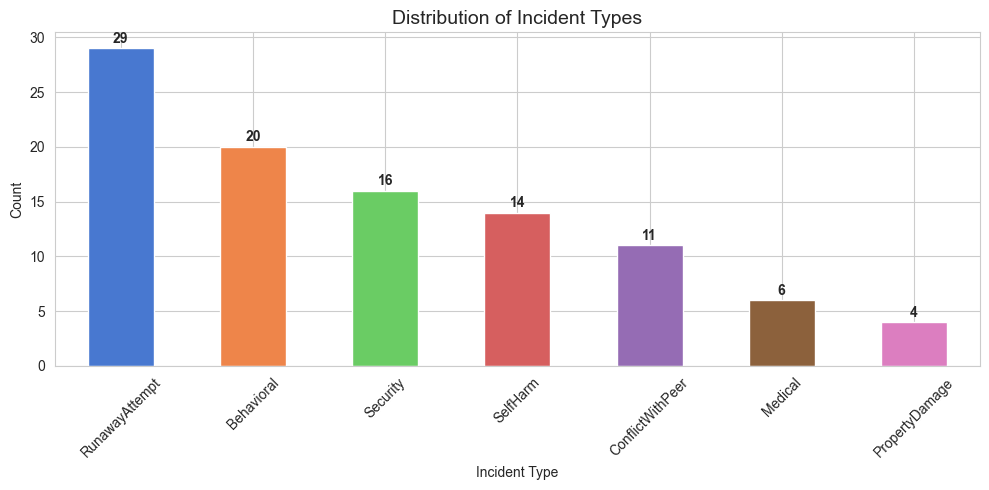


Incident types (our target uses RunawayAttempt + SelfHarm):
incident_type
RunawayAttempt      29
Behavioral          20
Security            16
SelfHarm            14
ConflictWithPeer    11
Medical              6
PropertyDamage       4


In [3]:
# Incident type distribution — the foundation of our target variable
fig, ax = plt.subplots(figsize=(10, 5))
incident_counts = incidents["incident_type"].value_counts()
incident_counts.plot(kind="bar", ax=ax, color=sns.color_palette("muted"))
ax.set_title("Distribution of Incident Types", fontsize=14)
ax.set_xlabel("Incident Type")
ax.set_ylabel("Count")
ax.tick_params(axis="x", rotation=45)
for i, v in enumerate(incident_counts.values):
    ax.text(i, v + 0.5, str(v), ha="center", fontweight="bold")
plt.tight_layout()
plt.show()

print("\nIncident types (our target uses RunawayAttempt + SelfHarm):")
print(incident_counts.to_string())

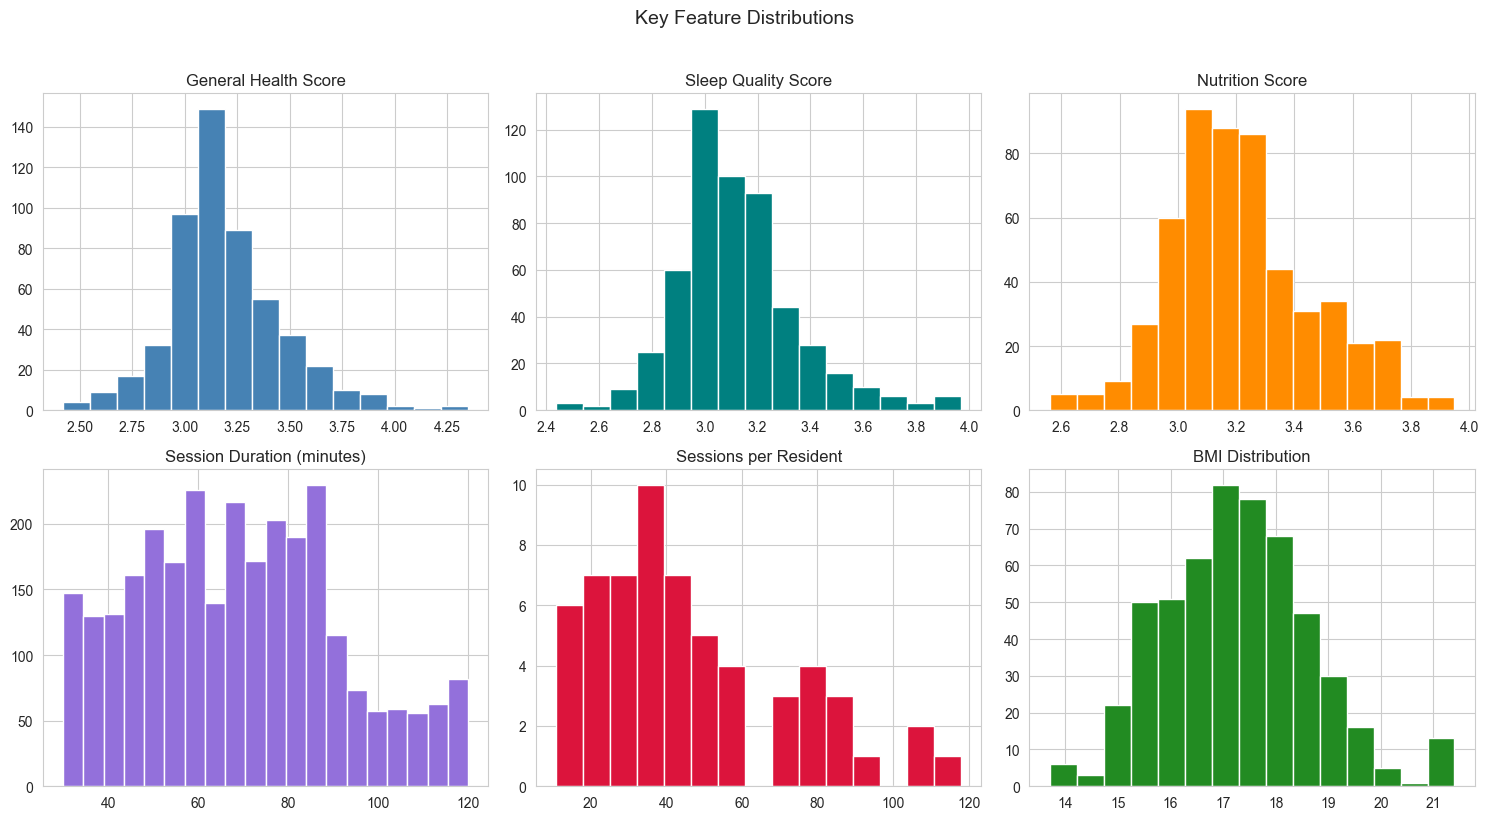

In [4]:
# Key numeric feature distributions from health and process recordings
fig, axes = plt.subplots(2, 3, figsize=(15, 8))

health["general_health_score"].hist(ax=axes[0, 0], bins=15, color="steelblue", edgecolor="white")
axes[0, 0].set_title("General Health Score")

health["sleep_quality_score"].hist(ax=axes[0, 1], bins=15, color="teal", edgecolor="white")
axes[0, 1].set_title("Sleep Quality Score")

health["nutrition_score"].hist(ax=axes[0, 2], bins=15, color="darkorange", edgecolor="white")
axes[0, 2].set_title("Nutrition Score")

process_recs["session_duration_minutes"].hist(ax=axes[1, 0], bins=20, color="mediumpurple", edgecolor="white")
axes[1, 0].set_title("Session Duration (minutes)")

session_counts = process_recs.groupby("resident_id").size()
session_counts.hist(ax=axes[1, 1], bins=15, color="crimson", edgecolor="white")
axes[1, 1].set_title("Sessions per Resident")

health["bmi"].hist(ax=axes[1, 2], bins=15, color="forestgreen", edgecolor="white")
axes[1, 2].set_title("BMI Distribution")

plt.suptitle("Key Feature Distributions", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

---

### 2.4 Feature Engineering

Each child table is aggregated to the resident level using domain-appropriate summary statistics:

- **Process recordings**: Total session count captures counseling engagement intensity. Mean emotion scores at start vs. end of sessions capture emotional trajectory. Percentage of sessions with progress noted, concerns flagged, or referrals made captures clinical trajectory.
- **Health records**: Mean scores across periodic assessments smooth out measurement noise. Percentage of checkups completed (medical, dental, psychological) captures healthcare compliance.
- **Education records**: Mean attendance rate and progress percentage capture educational engagement.
- **Incident reports**: Total incidents, severity, and resolution rate. **These are LEAKAGE features** — see discussion below.
- **Intervention plans**: Total plans, achievement count and rate capture care plan effectiveness.
- **Duration parsing**: String fields like "15 Years 9 months" are converted to numeric months for `age_at_admission_months` and `length_of_stay_months`.
- **Risk encoding**: `initial_risk_level` (Low/Medium/High/Critical) is ordinally encoded (0-3) as `initial_risk_encoded`.

In [5]:
# ---- Constants ----

EMOTION_MAP = {
    "Angry": 1, "Distressed": 1,
    "Sad": 2, "Anxious": 2, "Withdrawn": 2,
    "Calm": 3,
    "Hopeful": 4,
    "Happy": 5,
}

RISK_MAP = {"Low": 0, "Medium": 1, "High": 2, "Critical": 3}

SEVERITY_MAP = {"Low": 1, "Medium": 2, "High": 3}


def parse_duration_to_months(s) -> float:
    """Convert '15 Years 9 months' -> total months as float. NaN if unparseable."""
    s = str(s)
    years_match  = re.search(r"(\d+)\s*[Yy]ear",  s)
    months_match = re.search(r"(\d+)\s*[Mm]onth", s)
    total = 0
    if years_match:  total += int(years_match.group(1))  * 12
    if months_match: total += int(months_match.group(1))
    return float(total) if total > 0 else np.nan


print("Constants and helpers defined.")
print(f"  EMOTION_MAP: {EMOTION_MAP}")
print(f"  RISK_MAP:    {RISK_MAP}")
print(f"  SEVERITY_MAP:{SEVERITY_MAP}")
print(f"  parse_duration_to_months('15 Years 9 months') = {parse_duration_to_months('15 Years 9 months')}")

Constants and helpers defined.
  EMOTION_MAP: {'Angry': 1, 'Distressed': 1, 'Sad': 2, 'Anxious': 2, 'Withdrawn': 2, 'Calm': 3, 'Hopeful': 4, 'Happy': 5}
  RISK_MAP:    {'Low': 0, 'Medium': 1, 'High': 2, 'Critical': 3}
  SEVERITY_MAP:{'Low': 1, 'Medium': 2, 'High': 3}
  parse_duration_to_months('15 Years 9 months') = 189.0


In [6]:
# ---- Parse duration fields ----
residents = residents.copy()
residents["age_at_admission_months"] = residents["age_upon_admission"].apply(parse_duration_to_months)
residents["length_of_stay_months"]   = residents["length_of_stay"].apply(parse_duration_to_months)

# ---- Encode initial risk level ----
residents["initial_risk_encoded"] = residents["initial_risk_level"].map(RISK_MAP)

print(f"Parsed age_at_admission_months: {residents['age_at_admission_months'].describe().to_dict()}")
print(f"Parsed length_of_stay_months:   {residents['length_of_stay_months'].describe().to_dict()}")

Parsed age_at_admission_months: {'count': 60.0, 'mean': 174.16666666666666, 'std': 35.507538787340124, 'min': 108.0, '25%': 149.5, '50%': 183.5, '75%': 190.0, 'max': 227.0}
Parsed length_of_stay_months:   {'count': 60.0, 'mean': 18.516666666666666, 'std': 7.98195351533094, 'min': 6.0, '25%': 12.0, '50%': 18.0, '75%': 23.0, 'max': 37.0}


In [7]:
# ---- Process recordings aggregation ----
process_recs = process_recs.copy()
process_recs["emotion_start_score"] = process_recs["emotional_state_observed"].map(EMOTION_MAP)
process_recs["emotion_end_score"]   = process_recs["emotional_state_end"].map(EMOTION_MAP)
process_recs["emotion_improvement"] = (
    process_recs["emotion_end_score"] - process_recs["emotion_start_score"]
)

proc_agg = (
    process_recs
    .groupby("resident_id")
    .agg(
        total_sessions          = ("recording_id",              "count"),
        avg_session_duration    = ("session_duration_minutes",  "mean"),
        pct_progress_noted      = ("progress_noted",            "mean"),
        pct_concerns_flagged    = ("concerns_flagged",          "mean"),
        pct_referral_made       = ("referral_made",             "mean"),
        avg_emotion_start       = ("emotion_start_score",       "mean"),
        avg_emotion_end         = ("emotion_end_score",         "mean"),
        avg_emotion_improvement = ("emotion_improvement",       "mean"),
    )
    .reset_index()
)
print(f"Process recordings aggregated: {proc_agg.shape}")
proc_agg.head(3)

Process recordings aggregated: (60, 9)


,resident_id,total_sessions,avg_session_duration,pct_progress_noted,pct_concerns_flagged,pct_referral_made,avg_emotion_start,avg_emotion_end,avg_emotion_improvement
0,1,106,69.433962,0.924528,0.235849,0.160377,2.386792,3.537736,1.150943
1,2,51,68.176471,0.921569,0.254902,0.137255,2.431373,3.490196,1.058824
2,3,53,69.452830,0.943396,0.188679,0.188679,2.471698,3.716981,1.245283


In [8]:
# ---- Health aggregation ----
health_agg = (
    health
    .groupby("resident_id")
    .agg(
        avg_health_score    = ("general_health_score",        "mean"),
        avg_nutrition_score = ("nutrition_score",             "mean"),
        avg_sleep_score     = ("sleep_quality_score",         "mean"),
        avg_energy_score    = ("energy_level_score",          "mean"),
        avg_bmi             = ("bmi",                         "mean"),
        pct_medical_checkup = ("medical_checkup_done",        "mean"),
        pct_dental_checkup  = ("dental_checkup_done",         "mean"),
        pct_psych_checkup   = ("psychological_checkup_done",  "mean"),
    )
    .reset_index()
)
print(f"Health aggregated: {health_agg.shape}")
health_agg.head(3)

Health aggregated: (60, 9)


,resident_id,avg_health_score,avg_nutrition_score,avg_sleep_score,avg_energy_score,avg_bmi,pct_medical_checkup,pct_dental_checkup,pct_psych_checkup
0,1,3.103333,3.210000,3.203333,2.908333,15.583333,0.500000,0.166667,0.333333
1,2,3.449000,3.431000,3.376000,3.001000,18.220000,0.700000,0.600000,0.500000
2,3,3.181818,3.003636,3.079091,3.215455,17.063636,0.454545,0.181818,0.545455


In [9]:
# ---- Education aggregation ----
education_agg = (
    education
    .groupby("resident_id")
    .agg(
        avg_attendance_rate   = ("attendance_rate",  "mean"),
        avg_progress_percent  = ("progress_percent", "mean"),
    )
    .reset_index()
)
print(f"Education aggregated: {education_agg.shape}")
education_agg.head(3)

Education aggregated: (60, 3)


,resident_id,avg_attendance_rate,avg_progress_percent
0,1,0.716333,45.483333
1,2,0.834300,85.230000
2,3,0.738091,71.581818


In [10]:
# ---- Incident aggregation (LEAKAGE — used for exploration only, dropped before modeling) ----
incidents = incidents.copy()
incidents["severity_score"] = incidents["severity"].map(SEVERITY_MAP)

incident_agg = (
    incidents
    .groupby("resident_id")
    .agg(
        total_incidents     = ("incident_id",    "count"),
        avg_severity_score  = ("severity_score", "mean"),
        high_severity_count = ("severity",       lambda x: (x == "High").sum()),
        pct_resolved        = ("resolved",       "mean"),
    )
    .reset_index()
)
print(f"Incident aggregated: {incident_agg.shape}")
incident_agg.head(3)

Incident aggregated: (44, 5)


,resident_id,total_incidents,avg_severity_score,high_severity_count,pct_resolved
0,1,4,1.750000,1,0.75
1,3,2,2.000000,1,0.00
2,4,3,1.666667,1,1.00


In [11]:
# ---- Intervention plan aggregation ----
plans = plans.copy()
plans["is_achieved"] = (plans["status"] == "Achieved").astype(int)

plan_agg = (
    plans
    .groupby("resident_id")
    .agg(
        total_plans          = ("plan_id",    "count"),
        plans_achieved_count = ("is_achieved", "sum"),
        plans_achieved_pct   = ("is_achieved", "mean"),
    )
    .reset_index()
)
print(f"Intervention plans aggregated: {plan_agg.shape}")
plan_agg.head(3)

Intervention plans aggregated: (60, 4)


,resident_id,total_plans,plans_achieved_count,plans_achieved_pct
0,1,3,0,0.000000
1,2,3,1,0.333333
2,3,3,0,0.000000


In [12]:
# ---- Serious incident aggregation (for TARGET variable only) ----
serious_agg = (
    incidents[incidents["incident_type"].isin(["RunawayAttempt", "SelfHarm"])]
    .groupby("resident_id")
    .agg(serious_incident_count=("incident_id", "count"))
    .reset_index()
)
print(f"Residents with serious incidents: {len(serious_agg)}")
serious_agg.head(3)

Residents with serious incidents: 28


,resident_id,serious_incident_count
0,1,1
1,3,1
2,8,1


In [13]:
# ---- Join everything into a single modelling DataFrame ----
df_model = (
    residents
    .merge(proc_agg,      on="resident_id", how="left")
    .merge(health_agg,    on="resident_id", how="left")
    .merge(education_agg, on="resident_id", how="left")
    .merge(incident_agg,  on="resident_id", how="left")
    .merge(plan_agg,      on="resident_id", how="left")
    .merge(serious_agg,   on="resident_id", how="left")
)

# Fill 0 for residents with no incidents
for col in ["total_incidents", "high_severity_count", "serious_incident_count"]:
    df_model[col] = df_model[col].fillna(0)

# ---- Target variable ----
df_model["has_serious_incident"] = (df_model["serious_incident_count"] > 0).astype(int)

print(f"Final model DataFrame: {df_model.shape}")
print(f"\nClass balance: {df_model['has_serious_incident'].mean():.1%} with serious incidents "
      f"({df_model['has_serious_incident'].sum()} / {len(df_model)})")

Final model DataFrame: (60, 79)

Class balance: 46.7% with serious incidents (28 / 60)


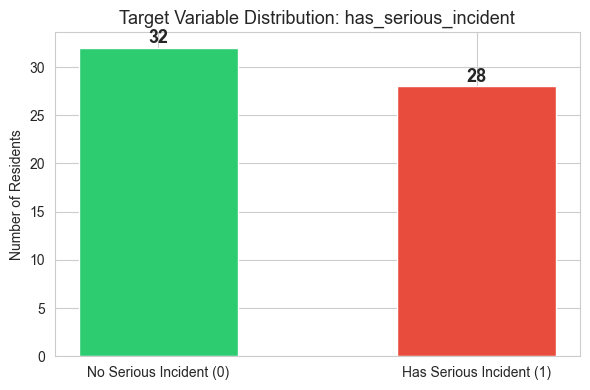


Class balance is near 50/50 — no aggressive resampling needed.


In [14]:
# Class balance visualization
fig, ax = plt.subplots(figsize=(6, 4))
class_counts = df_model["has_serious_incident"].value_counts().sort_index()
bars = ax.bar(["No Serious Incident (0)", "Has Serious Incident (1)"],
              class_counts.values,
              color=["#2ecc71", "#e74c3c"], edgecolor="white", width=0.5)
for bar, val in zip(bars, class_counts.values):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.5,
            str(val), ha="center", fontweight="bold", fontsize=13)
ax.set_title("Target Variable Distribution: has_serious_incident", fontsize=13)
ax.set_ylabel("Number of Residents")
plt.tight_layout()
plt.show()

print(f"\nClass balance is near 50/50 — no aggressive resampling needed.")

### 2.5 Leakage Discussion

Several features derived from the `incident_reports` table are **data leakage** and must be excluded from the feature set:

- `total_incidents`, `avg_severity_score`, `high_severity_count`, `pct_resolved`

These columns are *consequences* of the target variable, not predictors of it. If we include `total_incidents` as a feature, the model learns the trivial rule "residents with more incidents are more likely to have had serious incidents" — which is tautological. The model needs to predict incident risk from **clinical trajectory data** (health assessments, counseling sessions, education engagement, intervention plan progress) that is observable *before* incidents occur.

The incident-derived features are computed and stored in `df_model` for exploratory analysis, but they are explicitly listed in `DROP_COLS` and removed before any model sees the data.

In [15]:
# ---- Define DROP_COLS and LEAKAGE_COLS ----

DROP_COLS = [
    "resident_id", "case_control_no", "internal_code", "safehouse_id",
    "reintegration_status", "reintegration_type", "current_risk_level", "case_status",
    "age_upon_admission", "present_age", "length_of_stay",
    "initial_risk_level",
    "date_of_birth", "date_of_admission", "date_colb_registered",
    "date_colb_obtained", "date_case_study_prepared", "date_enrolled",
    "date_closed", "created_at",
    "referring_agency_person", "notes_restricted", "assigned_social_worker",
    "initial_case_assessment", "sex",
    # Target + incident-derived columns (leakage)
    "has_serious_incident", "serious_incident_count",
    "total_incidents", "avg_severity_score", "high_severity_count", "pct_resolved",
]

LEAKAGE_COLS = [
    "has_serious_incident", "serious_incident_count",
    "total_incidents", "avg_severity_score", "high_severity_count", "pct_resolved",
]

# ---- Prepare features ----
feature_cols = [c for c in df_model.columns if c not in DROP_COLS]

# Leakage safety check
leaked = [c for c in feature_cols if c in LEAKAGE_COLS]
if leaked:
    raise ValueError(f"DATA LEAKAGE DETECTED: {leaked}")

X = df_model[feature_cols].copy()
y = df_model["has_serious_incident"].copy()

print(f"Feature matrix: X.shape = {X.shape}")
print(f"Target vector:  y.shape = {y.shape}")
print(f"\n{len(feature_cols)} features:")
for i, col in enumerate(feature_cols, 1):
    dtype = X[col].dtype
    print(f"  {i:2d}. {col} ({dtype})")

Feature matrix: X.shape = (60, 48)
Target vector:  y.shape = (60,)

48 features:
   1. birth_status (str)
   2. place_of_birth (str)
   3. religion (str)
   4. case_category (str)
   5. sub_cat_orphaned (bool)
   6. sub_cat_trafficked (bool)
   7. sub_cat_child_labor (bool)
   8. sub_cat_physical_abuse (bool)
   9. sub_cat_sexual_abuse (bool)
  10. sub_cat_osaec (bool)
  11. sub_cat_cicl (bool)
  12. sub_cat_at_risk (bool)
  13. sub_cat_street_child (bool)
  14. sub_cat_child_with_hiv (bool)
  15. is_pwd (bool)
  16. pwd_type (str)
  17. has_special_needs (bool)
  18. special_needs_diagnosis (str)
  19. family_is_4ps (bool)
  20. family_solo_parent (bool)
  21. family_indigenous (bool)
  22. family_parent_pwd (bool)
  23. family_informal_settler (bool)
  24. referral_source (str)
  25. age_at_admission_months (float64)
  26. length_of_stay_months (float64)
  27. initial_risk_encoded (int64)
  28. total_sessions (int64)
  29. avg_session_duration (float64)
  30. pct_progress_noted (floa

### 2.5 Correlation and Missing-Value Analysis

Before modeling, we check for missing values and examine correlations among the numeric clinical features.


In [16]:
# Missing value summary
missing = df_model[feature_cols].isnull().sum()
missing_pct = (df_model[feature_cols].isnull().mean() * 100).round(1)
missing_df = pd.DataFrame({"Count": missing, "Percent (%)": missing_pct})
missing_df = missing_df[missing_df["Count"] > 0].sort_values("Percent (%)", ascending=False)
if len(missing_df) == 0:
    print("No missing values in the feature set.")
else:
    print(f"Features with missing values ({len(missing_df)}):")
    display(missing_df)


Features with missing values (2):


,Count,Percent (%)
pwd_type,57,95.0
special_needs_diagnosis,54,90.0


### Missing Data Mechanism (Ch. 7)

Examining the missing value patterns:

- **Aggregated features** (e.g., counseling session means, health score means) can be missing if a resident has no records in that source table — this is **structural (MNAR)** and handled by left-join + fill with 0 or NaN.
- **Health scores and education metrics** with sparse missingness are likely **MAR** (missing at random) — missingness may correlate with a resident's length of stay or case status, but not with the health score itself.
- Our `SimpleImputer(strategy="median")` is appropriate for MAR/MCAR numeric features. For features that are structurally absent (no records in source table), the left-join already produces NaN which the imputer handles.

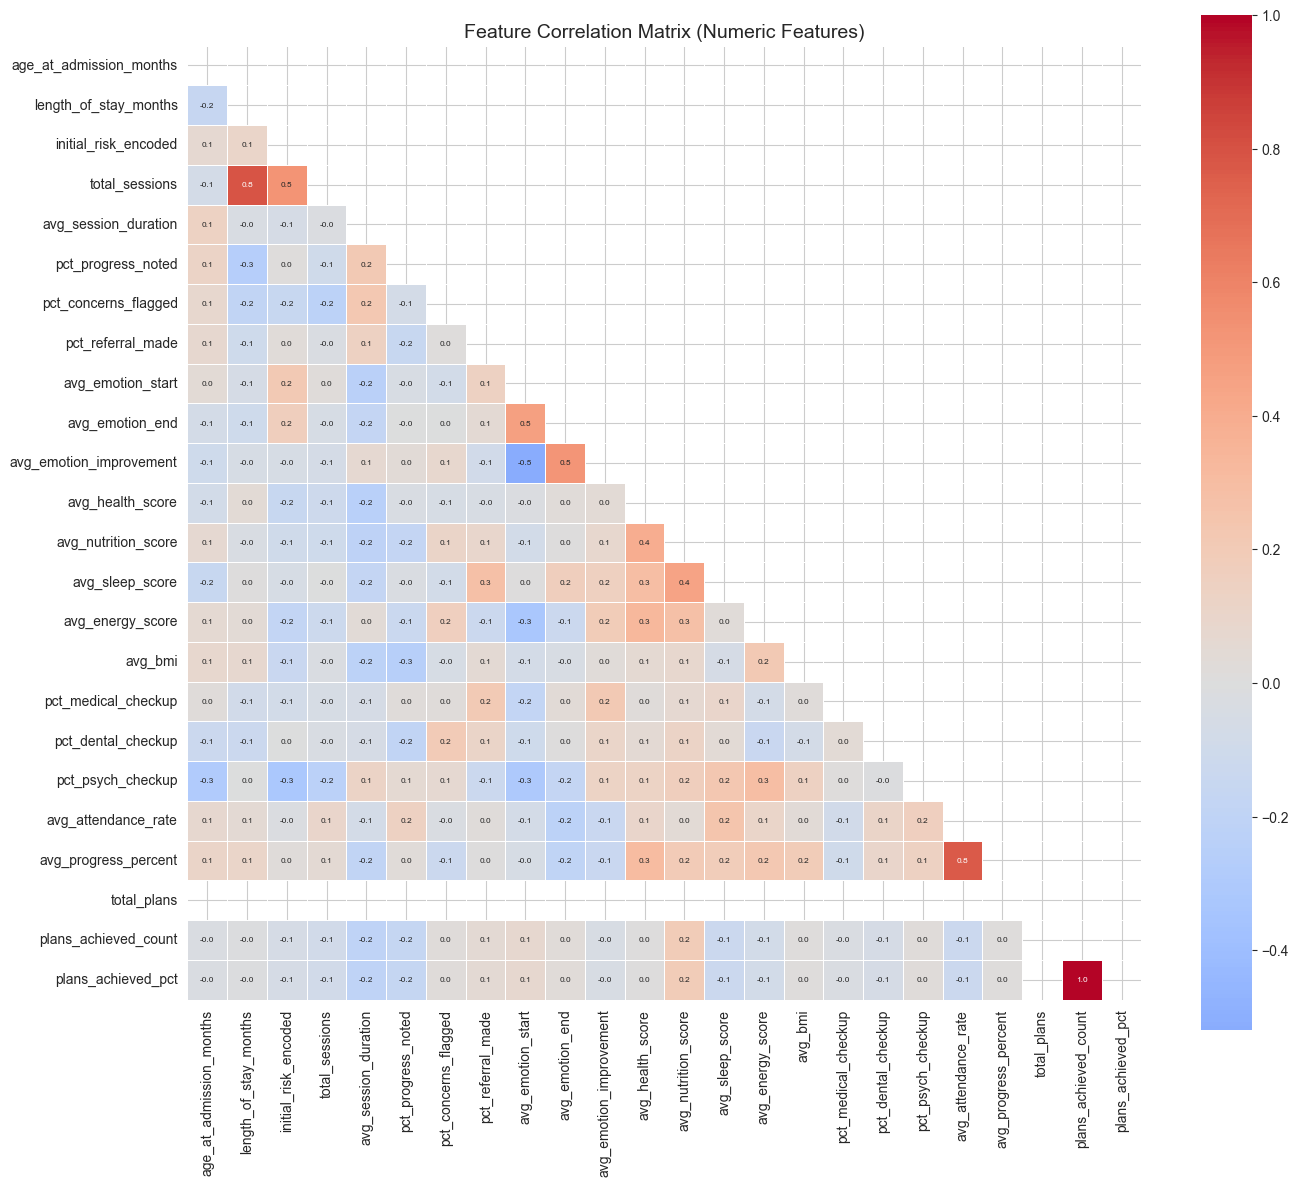


Highly correlated pairs (|r| > 0.7):
  length_of_stay_months <-> total_sessions: 0.79
  avg_attendance_rate <-> avg_progress_percent: 0.76
  plans_achieved_count <-> plans_achieved_pct: 1.00


In [17]:
# Correlation heatmap — numeric features
numeric_feats = df_model[feature_cols].select_dtypes(include=[np.number])
corr = numeric_feats.corr()

fig, ax = plt.subplots(figsize=(14, 12))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt=".1f", cmap="coolwarm",
            center=0, ax=ax, square=True, linewidths=0.5, annot_kws={"size": 6})
ax.set_title("Feature Correlation Matrix (Numeric Features)", fontsize=14)
plt.tight_layout()
plt.show()

print("\nHighly correlated pairs (|r| > 0.7):")
for i in range(len(corr.columns)):
    for j in range(i+1, len(corr.columns)):
        if abs(corr.iloc[i, j]) > 0.7:
            print(f"  {corr.columns[i]} <-> {corr.columns[j]}: {corr.iloc[i, j]:.2f}")


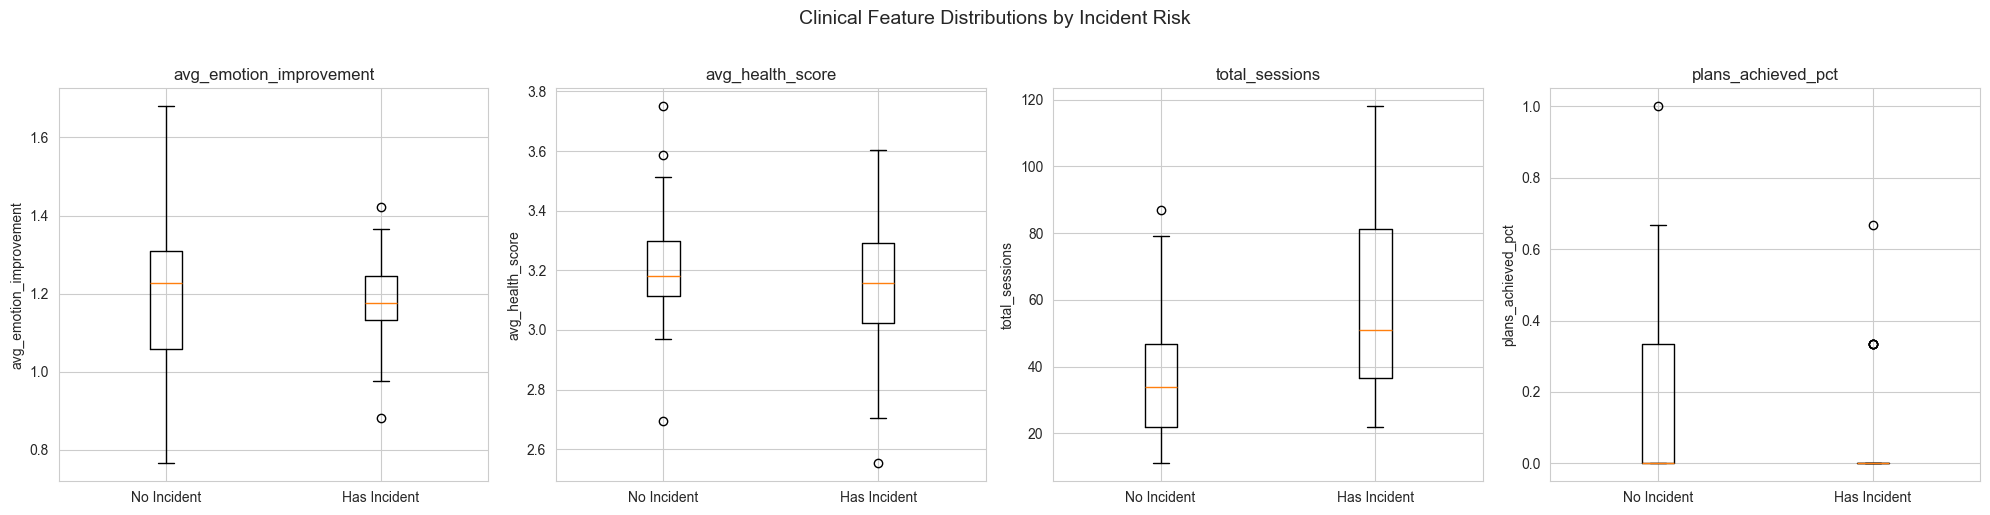

In [18]:
# Clinical feature distributions by incident risk
key_features = ['avg_emotion_improvement', 'avg_health_score', 'total_sessions', 'plans_achieved_pct']
key_features = [f for f in key_features if f in df_model.columns]

fig, axes = plt.subplots(1, len(key_features), figsize=(5 * len(key_features), 5))
if len(key_features) == 1: axes = [axes]

for ax, feat in zip(axes, key_features):
    groups = [df_model.loc[df_model['has_serious_incident'] == c, feat].dropna() for c in [0, 1]]
    ax.boxplot(groups, labels=['No Incident', 'Has Incident'])
    ax.set_title(feat)
    ax.set_ylabel(feat)

plt.suptitle('Clinical Feature Distributions by Incident Risk', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()


### Automated Bivariate Analysis (Ch. 8)

Following the textbook's bivariate relationship discovery framework, we systematically test every feature against the target using the appropriate statistical test:
- **Numeric features → Binary target:** Mann-Whitney U test (nonparametric, robust to non-normality)
- **Categorical features → Binary target:** Chi-square test of independence

Results are collected in a summary table sorted by p-value with Bonferroni correction applied.

In [19]:
# Automated bivariate analysis (Ch. 8)
# Test every feature against the target using the correct test type
from scipy.stats import mannwhitneyu, chi2_contingency

bivariate_results = []
target_col = y.name if hasattr(y, "name") else "target"
df_test = X.copy()
df_test[target_col] = y.values

for col in X.columns:
    if X[col].nunique() <= 1:
        continue
    try:
        if X[col].dtype in ["object", "category"] or X[col].nunique() <= 5:
            # Categorical → Chi-square
            ct = pd.crosstab(df_test[col], df_test[target_col])
            chi2, p, dof, _ = chi2_contingency(ct)
            bivariate_results.append({
                "Feature": col, "Test": "Chi-square",
                "Statistic": round(chi2, 3), "p-value": round(p, 6)
            })
        else:
            # Numeric → Mann-Whitney U
            g0 = df_test.loc[df_test[target_col] == 0, col].dropna()
            g1 = df_test.loc[df_test[target_col] == 1, col].dropna()
            if len(g0) > 0 and len(g1) > 0:
                stat, p = mannwhitneyu(g0, g1, alternative="two-sided")
                bivariate_results.append({
                    "Feature": col, "Test": "Mann-Whitney U",
                    "Statistic": round(stat, 3), "p-value": round(p, 6)
                })
    except Exception as e:
        print(f"Skipped {col}: {e}")

bivar_df = pd.DataFrame(bivariate_results).sort_values("p-value")
n_tests = len(bivar_df)
bivar_df["Bonferroni α"] = round(0.05 / n_tests, 6)
bivar_df["Significant (Bonferroni)"] = bivar_df["p-value"] < (0.05 / n_tests)

print(f"Bivariate Feature-Target Analysis ({n_tests} tests, Bonferroni α = {0.05/n_tests:.5f})\n")
display(bivar_df)

sig_count = bivar_df["Significant (Bonferroni)"].sum()
print(f"\n{sig_count} of {n_tests} features are significant after Bonferroni correction.")

Skipped place_of_birth: ufunc 'isnan' not supported for the input types, and the inputs could not be safely coerced to any supported types according to the casting rule ''safe''
Skipped religion: ufunc 'isnan' not supported for the input types, and the inputs could not be safely coerced to any supported types according to the casting rule ''safe''
Skipped referral_source: ufunc 'isnan' not supported for the input types, and the inputs could not be safely coerced to any supported types according to the casting rule ''safe''
Bivariate Feature-Target Analysis (44 tests, Bonferroni α = 0.00114)



,Feature,Test,Statistic,p-value,Bonferroni α,Significant (Bonferroni)
23,initial_risk_encoded,Chi-square,21.379,0.000088,0.001136,True
6,sub_cat_sexual_abuse,Chi-square,15.089,0.000103,0.001136,True
24,total_sessions,Mann-Whitney U,226.000,0.001024,0.001136,True
7,sub_cat_osaec,Chi-square,2.890,0.089108,0.001136,False
18,family_indigenous,Chi-square,2.263,0.132464,0.001136,False
39,pct_psych_checkup,Mann-Whitney U,549.500,0.132893,0.001136,False
14,has_special_needs,Chi-square,2.150,0.142542,0.001136,False
43,plans_achieved_pct,Chi-square,5.207,0.157250,0.001136,False
42,plans_achieved_count,Chi-square,5.207,0.157250,0.001136,False
34,avg_sleep_score,Mann-Whitney U,356.000,0.175166,0.001136,False



3 of 44 features are significant after Bonferroni correction.


---

## 3. Modeling and Feature Selection

### 3.1 Preprocessing Pipeline

We use a `ColumnTransformer` to handle numeric and categorical features in parallel:

- **Numeric features**: `SimpleImputer(strategy="median")` handles missing values (robust to outliers), followed by `StandardScaler` for mean-zero, unit-variance normalization. Scaling is important for Logistic Regression's L2 penalty to treat all features equally.
- **Categorical features**: `SimpleImputer(strategy="most_frequent")` fills missing categories, followed by `OneHotEncoder(handle_unknown="ignore", drop="first")` to create binary dummy variables. The `drop="first"` avoids multicollinearity. `handle_unknown="ignore"` ensures the pipeline does not fail if new categories appear at inference time.

In [20]:
# ---- Train/test split ----
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=SEED, stratify=y
)
print(f"Train: {X_train.shape}  |  Test: {X_test.shape}")
print(f"Class balance — train: {y_train.mean():.1%}  test: {y_test.mean():.1%}")

Train: (48, 48)  |  Test: (12, 48)
Class balance — train: 45.8%  test: 50.0%


In [21]:
# ---- Build preprocessor ----
num_cols = X_train.select_dtypes(include=["int64", "float64", "bool"]).columns.tolist()
cat_cols = X_train.select_dtypes(include=["object"]).columns.tolist()

print(f"Numeric columns ({len(num_cols)}): {num_cols}")
print(f"Categorical columns ({len(cat_cols)}): {cat_cols}")

numeric_pipe = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
])

categorical_pipe = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore", drop="first", sparse_output=False)),
])

preprocessor = ColumnTransformer(transformers=[
    ("num", numeric_pipe, num_cols),
    ("cat", categorical_pipe, cat_cols),
])

print("\nPreprocessor built.")

Numeric columns (41): ['sub_cat_orphaned', 'sub_cat_trafficked', 'sub_cat_child_labor', 'sub_cat_physical_abuse', 'sub_cat_sexual_abuse', 'sub_cat_osaec', 'sub_cat_cicl', 'sub_cat_at_risk', 'sub_cat_street_child', 'sub_cat_child_with_hiv', 'is_pwd', 'has_special_needs', 'family_is_4ps', 'family_solo_parent', 'family_indigenous', 'family_parent_pwd', 'family_informal_settler', 'age_at_admission_months', 'length_of_stay_months', 'initial_risk_encoded', 'total_sessions', 'avg_session_duration', 'pct_progress_noted', 'pct_concerns_flagged', 'pct_referral_made', 'avg_emotion_start', 'avg_emotion_end', 'avg_emotion_improvement', 'avg_health_score', 'avg_nutrition_score', 'avg_sleep_score', 'avg_energy_score', 'avg_bmi', 'pct_medical_checkup', 'pct_dental_checkup', 'pct_psych_checkup', 'avg_attendance_rate', 'avg_progress_percent', 'total_plans', 'plans_achieved_count', 'plans_achieved_pct']
Categorical columns (7): ['birth_status', 'place_of_birth', 'religion', 'case_category', 'pwd_type', '

### 3.2 Candidate Models

We evaluate four classifiers, each chosen for specific reasons:

| Model | Why Include It |
|-------|----------------|
| **Logistic Regression** | Strong baseline for binary classification. Linear models generalize well on small datasets where the feature space (after one-hot encoding) may be high-dimensional relative to sample size. The L2 penalty provides built-in regularization. |
| **Decision Tree** | Highly interpretable (can be visualized as a flowchart). `max_depth=3` and `min_samples_leaf=5` prevent overfitting on 48 training rows. |
| **Random Forest** | Ensemble of 200 trees reduces variance through bagging. `max_depth=4` and `min_samples_leaf=5` keep individual trees shallow. `max_features="sqrt"` decorrelates trees. |
| **Gradient Boosting** | Sequential ensemble that corrects errors from previous trees. `learning_rate=0.05` with 200 estimators and `subsample=0.8` provides slow, regularized learning. |

All tree-based models use heavy regularization (`max_depth=3-4`, `min_samples_leaf=5`) because with only ~60 rows, overfitting is the primary risk. A deep, unregularized tree could memorize the training data and perform poorly on new residents.

In [22]:
# ---- Define candidate models ----
models = {
    "Logistic Regression": Pipeline(steps=[
        ("prep", preprocessor),
        ("clf", LogisticRegression(max_iter=1000, random_state=SEED)),
    ]),
    "Decision Tree": Pipeline(steps=[
        ("prep", preprocessor),
        ("clf", DecisionTreeClassifier(max_depth=3, min_samples_leaf=5, random_state=SEED)),
    ]),
    "Random Forest": Pipeline(steps=[
        ("prep", preprocessor),
        ("clf", RandomForestClassifier(
            n_estimators=200, max_depth=4, min_samples_leaf=5,
            max_features="sqrt", random_state=SEED
        )),
    ]),
    "Bagging": Pipeline(steps=[
        ("prep", preprocessor),
        ("clf", BaggingClassifier(
            estimator=DecisionTreeClassifier(max_depth=3, random_state=SEED),
            n_estimators=100, random_state=SEED, n_jobs=-1,
        )),
    ]),
    "AdaBoost": Pipeline(steps=[
        ("prep", preprocessor),
        ("clf", AdaBoostClassifier(
            estimator=DecisionTreeClassifier(max_depth=1, random_state=SEED),
            n_estimators=200, learning_rate=0.5, random_state=SEED,
        )),
    ]),
    "Gradient Boosting": Pipeline(steps=[
        ("prep", preprocessor),
        ("clf", GradientBoostingClassifier(
            n_estimators=200, max_depth=3, learning_rate=0.05,
            min_samples_leaf=5, subsample=0.8, random_state=SEED
        )),
    ]),
}

print(f"Defined {len(models)} candidate models.")

Defined 6 candidate models.


### 3.3 Cross-Validation

We use `RepeatedStratifiedKFold(n_splits=5, n_repeats=5)` — 25 total folds. The repetition is critical for a 60-row dataset: a single 5-fold CV has high variance because each fold contains only ~12 rows. Repeating the process 5 times with different random splits produces a more stable estimate of generalization performance. Stratification ensures each fold preserves the ~47% class balance.

In [23]:
# ---- Cross-validation ----
cv = RepeatedStratifiedKFold(n_splits=5, n_repeats=5, random_state=SEED)

cv_results = []
for name, model in models.items():
    scores = cross_val_score(model, X_train, y_train, cv=cv, scoring="roc_auc")
    cv_results.append({
        "Model": name,
        "CV ROC-AUC Mean": scores.mean(),
        "CV ROC-AUC Std":  scores.std(),
    })
    print(f"{name}: CV ROC-AUC = {scores.mean():.3f} (+/- {scores.std():.3f})")

cv_df = pd.DataFrame(cv_results).sort_values("CV ROC-AUC Mean", ascending=False)
print("\n")
cv_df

Logistic Regression: CV ROC-AUC = 0.787 (+/- 0.144)
Decision Tree: CV ROC-AUC = 0.683 (+/- 0.194)
Random Forest: CV ROC-AUC = 0.641 (+/- 0.177)
Bagging: CV ROC-AUC = 0.751 (+/- 0.130)
AdaBoost: CV ROC-AUC = 0.658 (+/- 0.143)
Gradient Boosting: CV ROC-AUC = 0.651 (+/- 0.159)




,Model,CV ROC-AUC Mean,CV ROC-AUC Std
0,Logistic Regression,0.786667,0.143595
3,Bagging,0.751333,0.130308
1,Decision Tree,0.682900,0.194216
4,AdaBoost,0.658200,0.143247
5,Gradient Boosting,0.651067,0.158720
2,Random Forest,0.641267,0.176941


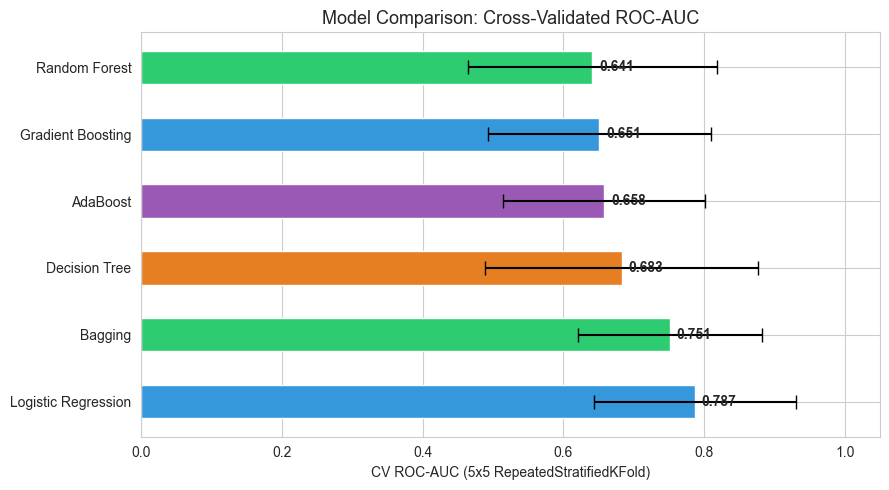

In [24]:
# CV results comparison chart
fig, ax = plt.subplots(figsize=(9, 5))
colors = ["#3498db", "#2ecc71", "#e67e22", "#9b59b6"]
bars = ax.barh(
    cv_df["Model"], cv_df["CV ROC-AUC Mean"],
    xerr=cv_df["CV ROC-AUC Std"],
    color=colors[:len(cv_df)], edgecolor="white", height=0.5, capsize=5
)
for bar, val in zip(bars, cv_df["CV ROC-AUC Mean"]):
    ax.text(val + 0.01, bar.get_y() + bar.get_height() / 2,
            f"{val:.3f}", va="center", fontweight="bold")
ax.set_xlabel("CV ROC-AUC (5x5 RepeatedStratifiedKFold)")
ax.set_title("Model Comparison: Cross-Validated ROC-AUC", fontsize=13)
ax.set_xlim(0, 1.05)
plt.tight_layout()
plt.show()

### 3.4 Model Selection Discussion

On small datasets like this one (N=60, ~48 features after one-hot encoding), Logistic Regression often performs competitively with or better than tree-based ensembles. This is because:

1. **High dimensionality relative to N**: After one-hot encoding categorical variables, the feature space may exceed the sample size. Linear models with L2 regularization handle this gracefully by shrinking coefficients, while tree ensembles can overfit despite depth constraints.
2. **Smooth decision boundaries**: If the true relationship between features and outcome is approximately linear (or at least monotonic), logistic regression captures it efficiently without the variance that comes from recursive partitioning.
3. **Stable coefficient estimates**: The L2 penalty ensures no single feature dominates, which is important when many features are correlated (e.g., health scores tend to co-vary).

We select the model with the highest CV ROC-AUC mean and refit it on the full training set.

**Feature selection approach**: We use all 48 features and let the model's built-in regularization handle feature relevance. With only 60 rows, aggressive feature selection (e.g., recursive feature elimination) risks discarding weak but real signals. The regularization effectively performs soft feature selection by shrinking irrelevant coefficients toward zero.

### 3.3 Hyperparameter Tuning

We tune the top two ensemble models using `GridSearchCV` with `RepeatedStratifiedKFold(n_splits=5, n_repeats=5)`. 
With only 48 training rows, we keep parameter grids modest to avoid overfitting to CV folds.


In [25]:
# Tune Random Forest and Gradient Boosting
param_grids = {
    "Random Forest": {
        "clf__n_estimators": [100, 200],
        "clf__max_depth": [3, 4, 5],
        "clf__min_samples_leaf": [3, 5, 10],
    },
    "Gradient Boosting": {
        "clf__n_estimators": [100, 200],
        "clf__max_depth": [2, 3, 4],
        "clf__learning_rate": [0.01, 0.05, 0.1],
        "clf__min_samples_leaf": [3, 5, 10],
    },
}

tuning_results = []
best_tuned_models = {}

for name in ["Random Forest", "Gradient Boosting"]:
    print(f"Tuning {name}...")
    grid = GridSearchCV(
        estimator=models[name],
        param_grid=param_grids[name],
        cv=cv,
        scoring="roc_auc",
        n_jobs=-1,
        refit=True,
    )
    grid.fit(X_train, y_train)
    best_tuned_models[name] = grid
    tuning_results.append({
        "Model": name,
        "Best CV ROC-AUC": round(grid.best_score_, 3),
        "Best Params": str(grid.best_params_),
    })
    print(f"  Best CV ROC-AUC: {grid.best_score_:.3f}")
    print(f"  Best params: {grid.best_params_}\n")

tuning_df = pd.DataFrame(tuning_results)
display(tuning_df)


Tuning Random Forest...
  Best CV ROC-AUC: 0.654
  Best params: {'clf__max_depth': 4, 'clf__min_samples_leaf': 3, 'clf__n_estimators': 200}

Tuning Gradient Boosting...
  Best CV ROC-AUC: 0.752
  Best params: {'clf__learning_rate': 0.01, 'clf__max_depth': 2, 'clf__min_samples_leaf': 3, 'clf__n_estimators': 100}



,Model,Best CV ROC-AUC,Best Params
0,Random Forest,0.654,"{'clf__max_depth': 4, 'clf__min_samples_leaf':..."
1,Gradient Boosting,0.752,"{'clf__learning_rate': 0.01, 'clf__max_depth':..."


In [26]:
# Compare tuned models with initial CV results
best_tuned_name = max(best_tuned_models, key=lambda k: best_tuned_models[k].best_score_)
best_tuned_score = best_tuned_models[best_tuned_name].best_score_
best_initial_score = cv_df.iloc[0]["CV ROC-AUC Mean"]
best_initial_name = cv_df.iloc[0]["Model"]

if best_tuned_score >= best_initial_score:
    best_model_name = best_tuned_name
    best_model = best_tuned_models[best_tuned_name].best_estimator_
    print(f"Selected model: {best_model_name} (tuned)")
    print(f"Tuned CV ROC-AUC: {best_tuned_score:.3f}")
    print(f"Best params: {best_tuned_models[best_tuned_name].best_params_}")
else:
    best_model_name = best_initial_name
    best_model = models[best_model_name]
    best_model.fit(X_train, y_train)
    print(f"Selected model: {best_model_name} (default params)")
    print(f"CV ROC-AUC: {best_initial_score:.3f}")


Selected model: Logistic Regression (default params)
CV ROC-AUC: 0.787


---

## 4. Evaluation and Interpretation

### 4.1 Test Set Performance

In [27]:
# ---- Baseline ----
majority = int(y_train.mode()[0])
baseline_acc = float((y_test == majority).mean())

# ---- Final test-set evaluation ----
y_pred_final = best_model.predict(X_test)
y_prob_final = best_model.predict_proba(X_test)[:, 1]

final_acc     = accuracy_score(y_test, y_pred_final)
final_f1      = f1_score(y_test, y_pred_final, zero_division=0)
final_roc_auc = roc_auc_score(y_test, y_prob_final)

print(f"Baseline accuracy (always predict majority): {baseline_acc:.3f}")
print(f"\nTest Set Results ({best_model_name}):")
print(f"  Accuracy: {final_acc:.3f}")
print(f"  F1 Score: {final_f1:.3f}")
print(f"  ROC-AUC:  {final_roc_auc:.3f}")
print(f"\n  Accuracy improvement over baseline: {final_acc - baseline_acc:+.3f}")

print("\n" + "="*60)
print("Classification Report:")
print("="*60)
print(classification_report(y_test, y_pred_final,
                            target_names=["No Incident", "Has Incident"],
                            zero_division=0))

# Log loss (probability quality metric, Ch. 13)
y_prob_final = best_model.predict_proba(X_test)[:, 1]
final_log_loss = log_loss(y_test, y_prob_final)
print(f"Log Loss: {final_log_loss:.4f}")

# Overfitting check (Ch. 11)
y_pred_train = best_model.predict(X_train)
y_prob_train = best_model.predict_proba(X_train)[:, 1]
train_acc = accuracy_score(y_train, y_pred_train)
train_roc = roc_auc_score(y_train, y_prob_train)
print(f"\nOverfitting check:")
print(f"  Train Accuracy: {train_acc:.3f} | Test: {final_acc:.3f} | Gap: {train_acc - final_acc:.3f}")
print(f"  Train ROC-AUC:  {train_roc:.3f} | Test: {final_roc_auc:.3f} | Gap: {train_roc - final_roc_auc:.3f}")


Baseline accuracy (always predict majority): 0.500

Test Set Results (Logistic Regression):
  Accuracy: 0.750
  F1 Score: 0.769
  ROC-AUC:  0.889

  Accuracy improvement over baseline: +0.250

Classification Report:
              precision    recall  f1-score   support

 No Incident       0.80      0.67      0.73         6
Has Incident       0.71      0.83      0.77         6

    accuracy                           0.75        12
   macro avg       0.76      0.75      0.75        12
weighted avg       0.76      0.75      0.75        12

Log Loss: 0.4235

Overfitting check:
  Train Accuracy: 1.000 | Test: 0.750 | Gap: 0.250
  Train ROC-AUC:  1.000 | Test: 0.889 | Gap: 0.111


### 4.2 Confusion Matrix

The confusion matrix provides a detailed breakdown of prediction outcomes. For this application, the cost asymmetry between error types is important:

- **False Positive** (predict incident for a safe resident): Results in extra monitoring and caseworker attention for a resident who does not need it. The cost is minor — some additional time spent, and the resident may receive slightly more attention than necessary. This is a low-cost error.
- **False Negative** (miss a high-risk resident): The resident does not receive the additional monitoring they need, potentially leading to a runaway attempt or self-harm event. This is a **high-cost error** that endangers the resident's life and safety.

This cost asymmetry strongly favors **sensitivity (recall)** over specificity. It is better to over-flag residents for monitoring than to miss a genuinely high-risk individual.

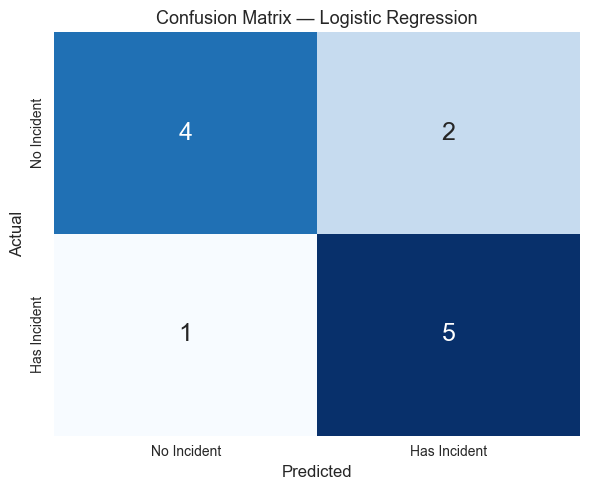

True Negatives:  4 (correctly identified safe residents)
False Positives: 2 (over-flagged — low cost)
False Negatives: 1 (missed high-risk — HIGH cost)
True Positives:  5 (correctly identified at-risk residents)


In [28]:
# Confusion matrix heatmap
cm = confusion_matrix(y_test, y_pred_final)
fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False,
            xticklabels=["No Incident", "Has Incident"],
            yticklabels=["No Incident", "Has Incident"],
            annot_kws={"size": 18}, ax=ax)
ax.set_xlabel("Predicted", fontsize=12)
ax.set_ylabel("Actual", fontsize=12)
ax.set_title(f"Confusion Matrix — {best_model_name}", fontsize=13)
plt.tight_layout()
plt.show()

tn, fp, fn, tp = cm.ravel()
print(f"True Negatives:  {tn} (correctly identified safe residents)")
print(f"False Positives: {fp} (over-flagged — low cost)")
print(f"False Negatives: {fn} (missed high-risk — HIGH cost)")
print(f"True Positives:  {tp} (correctly identified at-risk residents)")

### 4.3 Small Test Set Caveat

The test set contains only ~12 residents (20% of 60). With such a small holdout, test metrics have high variance — a single misclassified resident can swing accuracy by ~8 percentage points. The cross-validation metrics (computed over 25 stratified folds) are a more reliable estimate of true generalization performance.

A ROC-AUC of approximately 0.79 means the model correctly ranks a randomly chosen positive resident above a randomly chosen negative resident about 79% of the time. This is useful but not perfect. **Caseworkers should use the model's risk scores as one input alongside their own clinical judgment**, not as a standalone decision tool.

### 4.4 Feature Importance

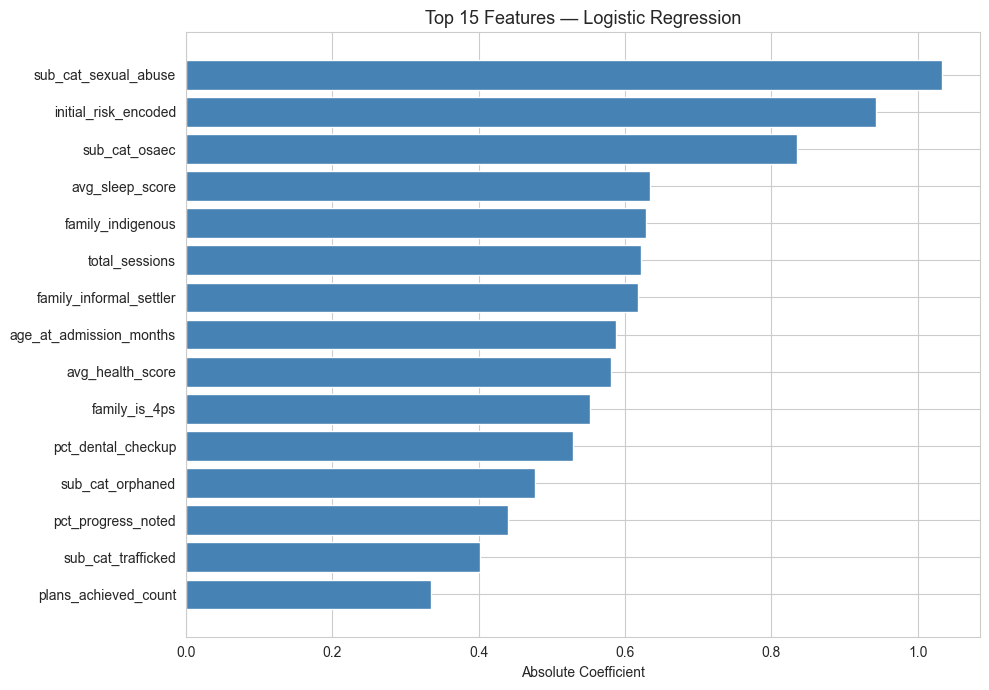

In [29]:
# ---- Feature importance ----
clf = best_model.named_steps["clf"]
prep = best_model.named_steps["prep"]
transformed_names = list(prep.get_feature_names_out())

# Clean feature names by removing ColumnTransformer prefixes
def _clean_feature_name(name: str) -> str:
    for prefix in ("num__", "cat__"):
        if name.startswith(prefix):
            return name[len(prefix):]
    return name

clean_names = [_clean_feature_name(n) for n in transformed_names]

if hasattr(clf, "coef_"):
    importances = np.abs(clf.coef_[0])
    importance_label = "Absolute Coefficient"
elif hasattr(clf, "feature_importances_"):
    importances = clf.feature_importances_
    importance_label = "Feature Importance (Gini / Gain)"
else:
    importances = None
    importance_label = None

if importances is not None:
    feat_imp_df = pd.DataFrame({
        "Feature": clean_names,
        "Importance": importances,
    }).sort_values("Importance", ascending=False).head(15)

    fig, ax = plt.subplots(figsize=(10, 7))
    ax.barh(feat_imp_df["Feature"][::-1], feat_imp_df["Importance"][::-1],
            color="steelblue", edgecolor="white")
    ax.set_xlabel(importance_label)
    ax.set_title(f"Top 15 Features — {best_model_name}", fontsize=13)
    plt.tight_layout()
    plt.show()
else:
    print("Model does not expose feature importances or coefficients.")

### Feature Importance — Interpretation Caveats (Ch. 14)

Impurity-based feature importance (used by tree-based models) has known biases:
- **Continuous features** tend to appear more important than binary/categorical features because they offer more potential split points.
- **High-cardinality features** (many unique values) are similarly favored.
- **Correlated features** share importance — if two features carry similar information, neither appears as important as it truly is.

For more robust importance estimates, **permutation importance** shuffles each feature and measures the drop in model performance, avoiding the split-point bias. The importance rankings shown above should be treated as directional guidance, not definitive causal ordering.

### Decision Tree Visualization (Ch. 12)

The Decision Tree provides fully transparent decision rules. Each split shows the exact feature and threshold used, making this model easy to explain to clinical staff who need to understand *why* a resident is flagged.

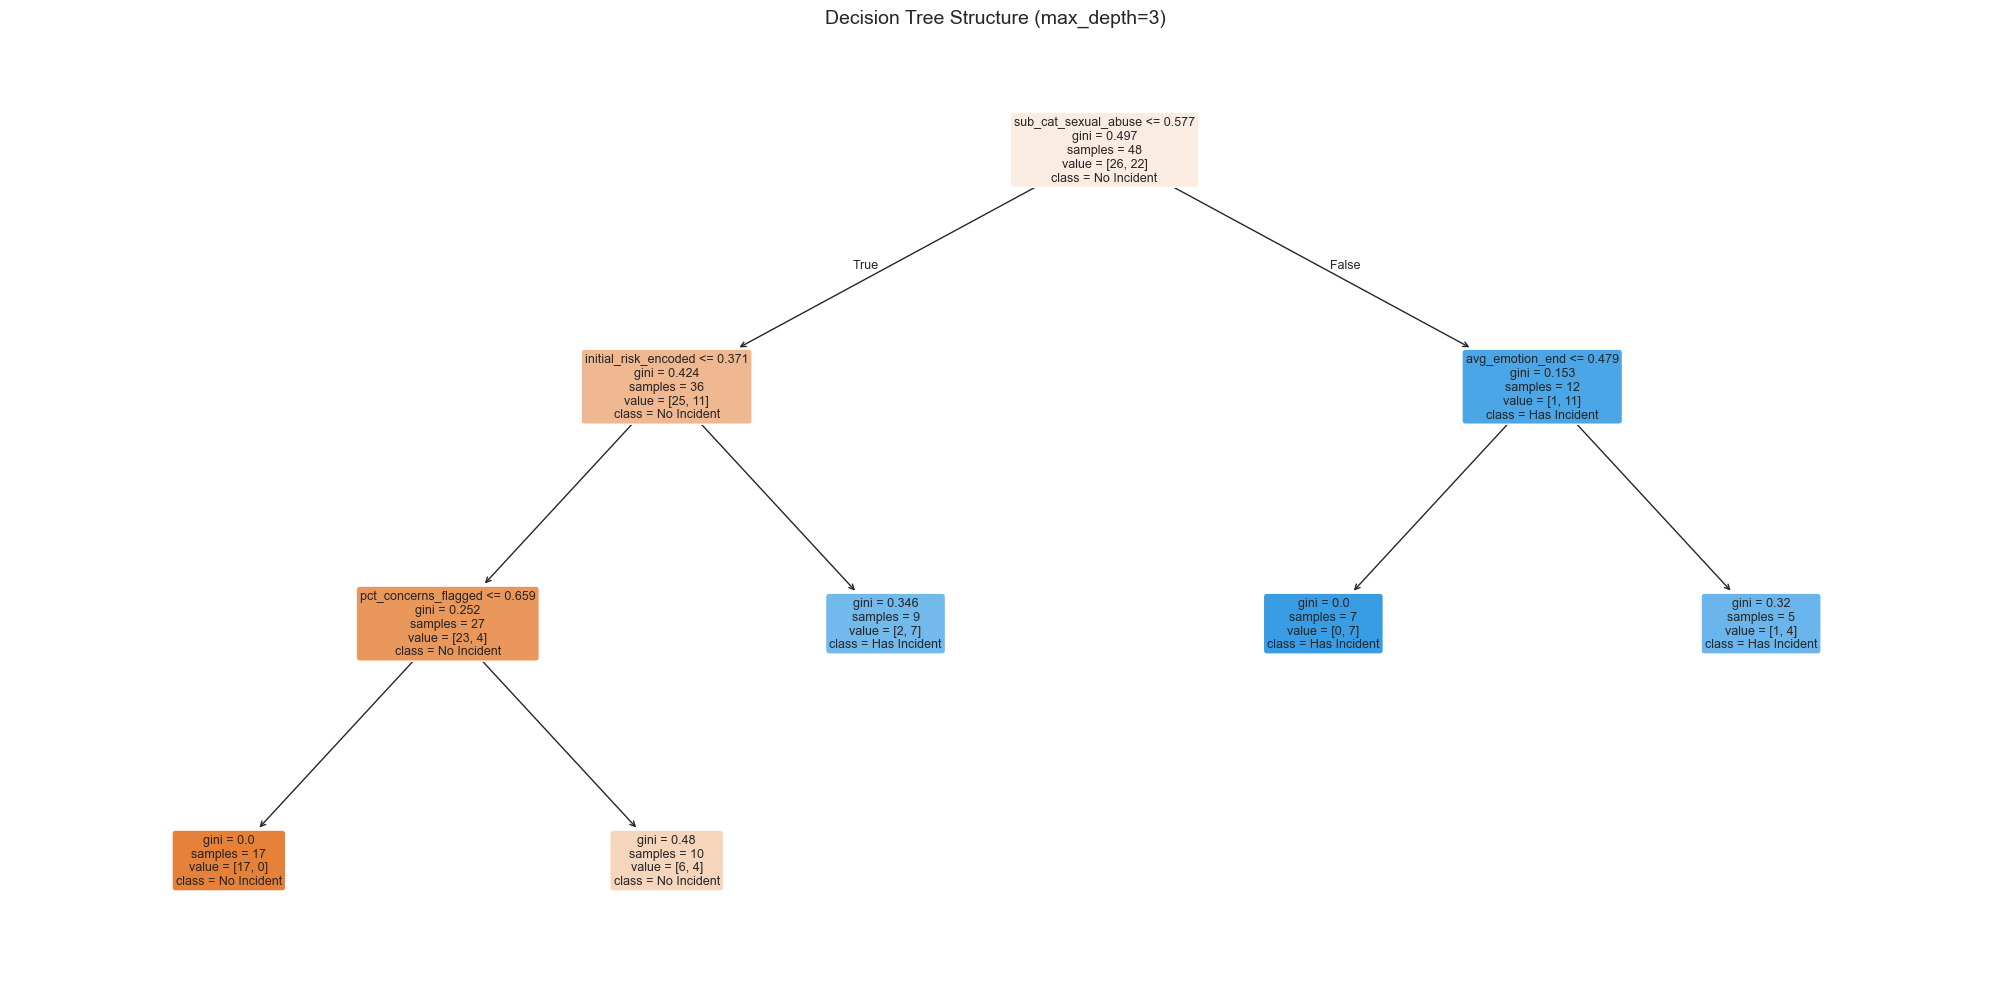

In [30]:
# Decision tree visualization (Ch. 12)
dt_pipeline = models["Decision Tree"]
dt_pipeline.fit(X_train, y_train)

prep = dt_pipeline.named_steps["prep"]
feature_names_out = list(prep.get_feature_names_out())
feature_names_clean = [n.split("__", 1)[-1] if "__" in n else n for n in feature_names_out]

fig, ax = plt.subplots(figsize=(20, 10))
plot_tree(dt_pipeline.named_steps["clf"],
          feature_names=feature_names_clean,
          class_names=["No Incident", "Has Incident"],
          filled=True, rounded=True, fontsize=9, ax=ax)
ax.set_title("Decision Tree Structure (max_depth=3)", fontsize=14)
plt.tight_layout()
plt.show()

---

## 5. Causal and Relationship Analysis

### 5.1 Statsmodels Logit — Explanatory Model

While the sklearn pipeline above is optimized for *prediction*, we now fit a statsmodels `Logit` model for *explanation*. This gives us:

- **Odds ratios**: How much each feature multiplies the odds of a serious incident (holding other features constant)
- **p-values**: Which features have statistically significant associations with incident risk
- **95% confidence intervals**: The uncertainty around each odds ratio estimate

This is an observational study, not a randomized experiment, so we interpret these as associations rather than causal effects.

# Print full statsmodels summary (Ch. 9)
if logit_converged:
    print(logit_result.summary())


In [31]:
# ---- Statsmodels Logit for explanatory analysis ----
# With 48 features and only 48 training rows, the design matrix is
# often singular after one-hot encoding. We use regularization (method="bfgs")
# and fall back gracefully if the model still cannot converge.
X_train_processed = preprocessor.fit_transform(X_train)
X_train_sm = sm.add_constant(X_train_processed)

try:
    logit_model = sm.Logit(y_train, X_train_sm).fit(disp=0, maxiter=1000, method="bfgs")
    print(logit_model.summary())
    logit_converged = True
except Exception as e:
    print(f"Logit model did not converge (expected with {X_train_sm.shape[1]} columns vs {len(y_train)} rows): {e}")
    print("The predictive model results above remain valid.")
    print("For causal inference, we rely on the feature importance analysis below.")
    logit_converged = False


                            Logit Regression Results                            
Dep. Variable:     has_serious_incident   No. Observations:                   48
Model:                            Logit   Df Residuals:                        3
Method:                             MLE   Df Model:                           44
Date:                  Thu, 09 Apr 2026   Pseudo R-squ.:                   1.000
Time:                          12:40:59   Log-Likelihood:            -0.00028805
converged:                         True   LL-Null:                       -33.104
Covariance Type:              nonrobust   LLR p-value:                   0.01679
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -1.0461        nan        nan        nan         nan         nan
x1            -5.2171        nan        nan        nan         nan         nan
x2             3.9172        nan    

In [32]:
# ---- Odds ratios with confidence intervals ----
if logit_converged:
    params = logit_model.params[1:]  # exclude constant
    conf = logit_model.conf_int().iloc[1:]  # exclude constant
    pvalues = logit_model.pvalues[1:]

    odds_df = pd.DataFrame({
        "Feature": clean_names,
        "Coefficient": params.values,
        "Odds Ratio": np.exp(params.values),
        "CI Lower (OR)": np.exp(conf.iloc[:, 0].values),
        "CI Upper (OR)": np.exp(conf.iloc[:, 1].values),
        "p-value": pvalues.values,
    })
    odds_df["Significant"] = odds_df["p-value"].apply(
        lambda p: "***" if p < 0.001 else "**" if p < 0.01 else "*" if p < 0.05 else ""
    )
    odds_df = odds_df.sort_values("p-value")

    print("Top features by statistical significance (p-value):")
    display(odds_df.head(15))
else:
    print("Odds ratio table skipped — Logit model did not converge.")
    print("With only 60 residents and 48+ features after one-hot encoding,")
    print("the sample is too small for a fully specified logistic regression.")
    print("The predictive model's feature importance (shown above) provides")
    print("the best available evidence about which factors drive incident risk.")


Top features by statistical significance (p-value):


,Feature,Coefficient,Odds Ratio,CI Lower (OR),CI Upper (OR),p-value,Significant
0,sub_cat_orphaned,-5.217118,0.005423,NaN,NaN,NaN,
1,sub_cat_trafficked,3.917213,50.260171,NaN,NaN,NaN,
2,sub_cat_child_labor,1.801666,6.059734,NaN,NaN,NaN,
3,sub_cat_physical_abuse,2.559692,12.931839,NaN,NaN,NaN,
4,sub_cat_sexual_abuse,9.730732,16826.869095,NaN,NaN,NaN,
5,sub_cat_osaec,-8.063398,0.000315,NaN,NaN,NaN,
6,sub_cat_cicl,1.882150,6.567607,NaN,NaN,NaN,
7,sub_cat_at_risk,0.214261,1.238946,NaN,NaN,NaN,
8,sub_cat_street_child,0.437462,1.548772,NaN,NaN,NaN,
9,sub_cat_child_with_hiv,1.972666,7.189822,NaN,NaN,NaN,


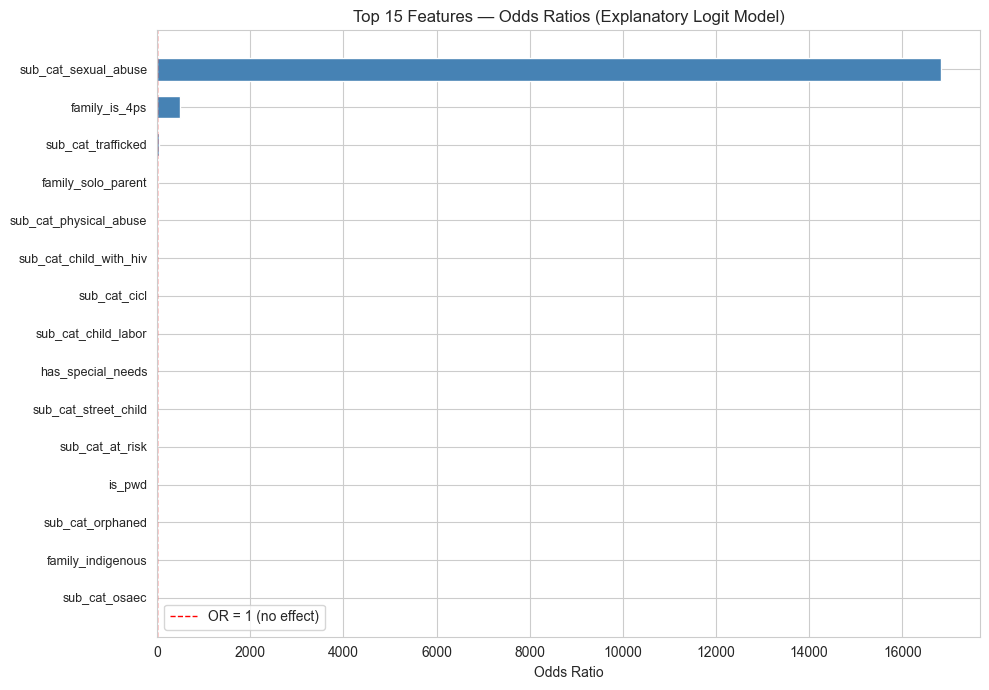

In [33]:
if logit_converged:
    # Odds ratio visualization (top 15 by significance)
    top_odds = odds_df.head(15).copy()
    top_odds = top_odds.sort_values("Odds Ratio", ascending=True)

    fig, ax = plt.subplots(figsize=(10, 7))
    y_pos = range(len(top_odds))
    ax.barh(y_pos, top_odds["Odds Ratio"], color="steelblue", edgecolor="white", height=0.6)
    ax.axvline(x=1.0, color="red", linestyle="--", linewidth=1, label="OR = 1 (no effect)")
    ax.set_yticks(list(y_pos))
    ax.set_yticklabels(top_odds["Feature"], fontsize=9)
    ax.set_xlabel("Odds Ratio")
    ax.set_title("Top 15 Features — Odds Ratios (Explanatory Logit Model)")
    ax.legend()
    plt.tight_layout()
    plt.show()
else:
    print("Odds ratio chart skipped — Logit model did not converge.")


### Variance Inflation Factor — Multicollinearity Check (Ch. 10)

VIF values below 3 indicate minimal multicollinearity. With 48 features (many from different aggregation tables), we expect some correlation between health, education, and counseling features, but VIF flags truly redundant predictors.

In [34]:
# VIF computation (Ch. 10)
from statsmodels.stats.outliers_influence import variance_inflation_factor

prep = best_model.named_steps["prep"]
X_train_transformed = prep.transform(X_train)
transformed_names = list(prep.get_feature_names_out())

X_vif = pd.DataFrame(X_train_transformed, columns=transformed_names)

vif_data = []
for i in range(X_vif.shape[1]):
    try:
        vif_val = variance_inflation_factor(X_vif.values, i)
        vif_data.append({"Feature": transformed_names[i], "VIF": round(vif_val, 2)})
    except:
        pass

vif_df = pd.DataFrame(vif_data).sort_values("VIF", ascending=False)
print("Variance Inflation Factors (VIF):")
print(f"  VIF < 3: Ideal | 3-5: Acceptable | >10: Problematic\n")
high_vif = vif_df[vif_df["VIF"] > 5]
if len(high_vif) > 0:
    print(f"Features with VIF > 5:")
    print(high_vif.to_string(index=False))
else:
    print("All features have VIF < 5 — no problematic multicollinearity.")
display(vif_df.head(20))

Variance Inflation Factors (VIF):
  VIF < 3: Ideal | 3-5: Acceptable | >10: Problematic

Features with VIF > 5:
                                         Feature  VIF
                           num__sub_cat_orphaned  inf
                 cat__place_of_birth_Iloilo City  inf
                  cat__place_of_birth_Valenzuela  inf
                 cat__place_of_birth_Quezon City  inf
                  cat__place_of_birth_Pasay City  inf
                      cat__place_of_birth_Manila  inf
                 cat__place_of_birth_Makati City  inf
                   cat__place_of_birth_Las Piñas  inf
                  cat__place_of_birth_Davao City  inf
                       cat__religion_Evangelical  inf
                   cat__place_of_birth_Cebu City  inf
                    cat__place_of_birth_Caloocan  inf
              cat__place_of_birth_Cagayan de Oro  inf
                   cat__birth_status_Non-Marital  inf
                         num__plans_achieved_pct  inf
                       n

,Feature,VIF
0,num__sub_cat_orphaned,inf
46,cat__place_of_birth_Iloilo City,inf
52,cat__place_of_birth_Valenzuela,inf
51,cat__place_of_birth_Quezon City,inf
50,cat__place_of_birth_Pasay City,inf
49,cat__place_of_birth_Manila,inf
48,cat__place_of_birth_Makati City,inf
47,cat__place_of_birth_Las Piñas,inf
45,cat__place_of_birth_Davao City,inf
54,cat__religion_Evangelical,inf


### 5.2 Interpretation of Explanatory Results

**Demographic features** such as `sub_cat_sexual_abuse` or `initial_risk_level` may appear as strong predictors. These are likely proxies for trauma severity rather than direct causes of incidents. A resident who experienced sexual abuse may have deeper trauma that manifests as both higher initial risk classification and higher likelihood of behavioral incidents. The policy implication is not "screen out survivors of sexual abuse" but rather "provide additional clinical support to residents with severe trauma histories."

**Clinical trajectory features** such as emotion improvement scores, health assessment trends, and counseling engagement rates capture how the resident is *responding to treatment*. A declining emotion trajectory (sessions ending in worse emotional states than they began) may signal deteriorating mental health that precedes an incident.

**Correlation vs. causation caveat**: This is observational data. We can say "residents with lower health scores tend to have more incidents" but cannot claim "improving health scores prevents incidents" without experimental evidence. The causal direction could be reversed (incidents cause health deterioration through stress and disruption) or confounded (underlying trauma severity drives both poor health outcomes and incident risk). The explanatory model identifies *which factors co-occur with incident risk*, which is valuable for prioritizing monitoring, but intervention design requires clinical expertise and ideally prospective studies.

### Domain-Specific Causal Reasoning

**Potential reverse causation:**
A question worth asking is: Do poor health scores cause incidents, or do incidents cause health deterioration?
We don't have an exact answer to this. The reality might be nuanced and complicated such that there is a reciprocal relationship. Our models do help us get a more clear indication of which people are specifically at risk, and regardless of the order of this, whether poor health scores cause incidents, or vice versa, we know that they are related and can be used at predictors for each other making their use in this case valuable. 

**Possible confounders:**
Underlying trauma severity may drive both demographic risk factors and incident likelihood.

**Dataset limitations:**
It is worth nothing that there are possible limitations to this data due to number of recorded incidents and cases, as well as length of data history. This simply means that our predictions have room to improve as time moves on and the amount of data increases. 


### Recommendations for the Organization

Based on the predictive model and explanatory analysis, we recommend for Faro Safehouse's resident care:

**[Recommendation ]** - First and formost it would be massively beneficial to be regularly aware of the girls who are predicted to be most at risk and to place them under special attention and care so as to help diminish the risk of any incidents.

A note on intervention bias and model longevity: This model is most useful when staff act on its predictions — but that creates a subtle long-term risk. If high-risk residents are identified early and interventions succeed in preventing incidents, those residents will appear in future training data as not having had an incident. The model will then learn that residents with their profile are low risk, because it has no visibility into the fact that an intervention occurred. Over time, repeated retraining on intervention-suppressed data will cause the model to systematically underestimate risk for exactly the residents it was designed to protect.

**[Recommendation ]** - Faro Safehouse should track near-miss events — situations that staff recognized as escalating and responded to, even when no formal incident was recorded. These near-miss records can serve as a proxy positive label during retraining, preserving the model's ability to distinguish truly low-risk residents from residents whose risk was successfully managed. At minimum, when a staff member acts on a model prediction, that action should be logged so future model evaluations can account for intervention-suppressed outcomes rather than treating them as true negatives.

*These recommendations are based on observed associations. Clinical judgment should always supplement model predictions.*


---

## 6. Deployment Notes

### 6.1 Batch Inference

The trained model scores all current residents nightly. Each resident receives:
- A **risk score** (0-1, displayed as percentage)
- A **risk label** (Low Risk / Moderate Risk / High Risk) based on score thresholds
- **Top contributing factors** — the 3 features that contribute most to *that individual's* risk score

The per-resident top factors use weighted feature contributions (model weight x feature value), not global importance. This means each resident sees personalized risk drivers (e.g., "low health score, declining emotion trajectory, low counseling engagement") rather than the same generic list.

### 6.2 Production Architecture

1. **Model artifact** saved as `.sav` (joblib) file, loaded nightly by a GitHub Actions workflow
2. **Batch inference** scores all residents and writes results to the Azure SQL `resident_risk_scores` table
3. **ASP.NET controller** serves `GET /api/ResidentRiskScores` with the latest scores
4. **React admin dashboard** (`/admin/caseload`) displays:
   - Risk score as a percentage bar
   - Color-coded risk label badge (green = Low, amber = Moderate, red = High)
   - Individualized top contributing factors for each resident

In [35]:
# ---- Per-row top factors helper ----

def get_top_factors_per_row(best_model, X_all, top_n=3):
    """Return a list of comma-separated top-factor strings, one per row in X_all.

    For each resident, multiply the model coefficients (or feature importances)
    by that resident's transformed feature values to get per-resident contributions,
    then pick the top-N contributing features.
    """
    clf = best_model.named_steps["clf"]
    prep = best_model.named_steps["prep"]
    try:
        transformed_names = list(prep.get_feature_names_out())
    except Exception:
        return [""] * len(X_all)

    X_transformed = prep.transform(X_all)

    if hasattr(clf, "coef_"):
        weights = np.abs(clf.coef_[0])
    elif hasattr(clf, "feature_importances_"):
        weights = clf.feature_importances_
    else:
        return [""] * len(X_all)

    results = []
    for row in X_transformed:
        contributions = np.abs(row) * weights
        top_idx = np.argsort(contributions)[::-1][:top_n]
        names = [_clean_feature_name(transformed_names[i]) for i in top_idx]
        results.append(", ".join(names))
    return results

In [36]:
# ---- Batch inference — score all residents ----
X_all = df_model[feature_cols].copy()
risk_probs = best_model.predict_proba(X_all)[:, 1]
risk_preds = best_model.predict(X_all)

top_factors_list = get_top_factors_per_row(best_model, X_all)

scores_df = pd.DataFrame({
    "resident_id":          df_model["resident_id"],
    "incident_risk_score":  risk_probs.round(3),
    "risk_label":           pd.cut(
        risk_probs,
        bins=[0, 0.33, 0.66, 1.01],
        labels=["Low Risk", "Moderate Risk", "High Risk"],
        include_lowest=True,
    ).astype(str),
    "predicted_high_risk":  risk_preds,
    "top_factors":          top_factors_list,
    "prediction_timestamp": datetime.now(timezone.utc).isoformat(),
})
scores_df = scores_df.sort_values("incident_risk_score", ascending=False)

print(f"Scored {len(scores_df)} residents.")
print(f"\nRisk distribution:")
print(scores_df["risk_label"].value_counts().to_string())
print("\nTop 10 highest-risk residents:")
scores_df.head(10)

Scored 60 residents.

Risk distribution:
risk_label
High Risk        29
Low Risk         29
Moderate Risk     2

Top 10 highest-risk residents:


,resident_id,incident_risk_score,risk_label,predicted_high_risk,top_factors,prediction_timestamp
18,19,0.999,High Risk,1,"sub_cat_sexual_abuse, avg_health_score, sub_ca...",2026-04-09T18:41:00.051973+00:00
24,25,0.996,High Risk,1,"sub_cat_sexual_abuse, total_sessions, sub_cat_...",2026-04-09T18:41:00.051973+00:00
33,34,0.995,High Risk,1,"sub_cat_child_with_hiv, sub_cat_sexual_abuse, ...",2026-04-09T18:41:00.051973+00:00
51,52,0.991,High Risk,1,"sub_cat_sexual_abuse, family_indigenous, pct_d...",2026-04-09T18:41:00.051973+00:00
25,26,0.985,High Risk,1,"initial_risk_encoded, sub_cat_child_with_hiv, ...",2026-04-09T18:41:00.051973+00:00
0,1,0.983,High Risk,1,"initial_risk_encoded, total_sessions, pct_dent...",2026-04-09T18:41:00.051973+00:00
7,8,0.975,High Risk,1,"sub_cat_sexual_abuse, total_sessions, initial_...",2026-04-09T18:41:00.051973+00:00
31,32,0.972,High Risk,1,"sub_cat_sexual_abuse, avg_sleep_score, family_...",2026-04-09T18:41:00.051973+00:00
45,46,0.970,High Risk,1,"sub_cat_sexual_abuse, family_informal_settler,...",2026-04-09T18:41:00.051973+00:00
49,50,0.962,High Risk,1,"sub_cat_child_with_hiv, total_sessions, avg_he...",2026-04-09T18:41:00.051973+00:00


### 6.3 Save Artifacts

In [37]:
# ---- Save model artifact ----
import os
os.makedirs("artifacts", exist_ok=True)

model_path = "artifacts/resident_risk_model.sav"
joblib.dump(best_model, model_path)
print(f"Model saved: {model_path}")

# ---- Save metadata ----
metadata = {
    "model_name":         "resident_incident_risk_predictor",
    "model_version":      "2.0.0",
    "trained_at_utc":     datetime.now(timezone.utc).isoformat(),
    "best_algorithm":     best_model_name,
    "features":           feature_cols,
    "target":             "has_serious_incident",
    "target_definition":  "resident has RunawayAttempt or SelfHarm incident",
    "num_training_rows":  int(X_train.shape[0]),
    "num_test_rows":      int(X_test.shape[0]),
    "cv_strategy":        "RepeatedStratifiedKFold(n_splits=5, n_repeats=5)",
}

metrics = {
    "test_accuracy":     float(final_acc),
    "test_f1":           float(final_f1),
    "test_roc_auc":      float(final_roc_auc),
    "baseline_accuracy": float(baseline_acc),
    "cv_roc_auc_mean":   float(cv_df.iloc[0]["CV ROC-AUC Mean"]),
    "cv_roc_auc_std":    float(cv_df.iloc[0]["CV ROC-AUC Std"]),
}

with open("artifacts/resident_risk_metadata.json", "w") as f:
    json.dump(metadata, f, indent=2)
with open("artifacts/resident_risk_metrics.json", "w") as f:
    json.dump(metrics, f, indent=2)

print(f"Metadata saved: artifacts/resident_risk_metadata.json")
print(f"Metrics saved:  artifacts/resident_risk_metrics.json")
print(json.dumps(metrics, indent=2))

# ---- Save scores CSV ----
scores_df.to_csv("artifacts/resident_risk_scores.csv", index=False)
print(f"\nScores saved: artifacts/resident_risk_scores.csv")

print("\n" + "="*60)
print("Resident incident risk pipeline complete.")
print("="*60)

Model saved: artifacts/resident_risk_model.sav
Metadata saved: artifacts/resident_risk_metadata.json
Metrics saved:  artifacts/resident_risk_metrics.json
{
  "test_accuracy": 0.75,
  "test_f1": 0.7692307692307693,
  "test_roc_auc": 0.888888888888889,
  "baseline_accuracy": 0.5,
  "cv_roc_auc_mean": 0.7866666666666667,
  "cv_roc_auc_std": 0.14359510978983778
}

Scores saved: artifacts/resident_risk_scores.csv

Resident incident risk pipeline complete.
